In [ ]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/ESPECIALIZACIÓN/MÉTODOS ESTADISTICOS/Anexo 1 - Base de Datos dynamic_pricing.csv")
data.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [ ]:
data.columns

Index(['Number_of_Riders', 'Number_of_Drivers', 'Location_Category',
       'Customer_Loyalty_Status', 'Number_of_Past_Rides', 'Average_Ratings',
       'Time_of_Booking', 'Vehicle_Type', 'Expected_Ride_Duration',
       'Historical_Cost_of_Ride'],
      dtype='object')

In [ ]:
# 2. Ajuste del modelo de regresión lineal múltiple usando las equivalencias correctas
data_model = data[['Average_Ratings', 'Number_of_Riders', 'Expected_Ride_Duration','Customer_Loyalty_Status']]
data_model.head()

,Average_Ratings,Number_of_Riders,Expected_Ride_Duration,Customer_Loyalty_Status
0,4.47,90,90,Silver
1,4.06,58,43,Silver
2,3.99,42,76,Silver
3,4.31,89,134,Regular
4,3.77,78,149,Regular


Punto 2.1 y 2.2: Ajuste del modelo de regresión lineal múltiple
* Definir la variable dependiente (Trip_Rating) y los tres predictores
* Ajustar el modelo con statsmodels (Python) u lm() (R)
* Extraer y presentar:
   Ecuación estimada del modelo: Trip_Rating = β₀ + β₁·Trip_Distance + β₂·Number_of_Riders + β₃·Customer_Loyalty
* Coeficientes β con interpretación individual
* Valores p de significancia estadística
* R² y R² ajustado

In [ ]:
print("Categorías en Customer_Loyalty_Status:")
print(data_model["Customer_Loyalty_Status"].value_counts())

Categorías en Customer_Loyalty_Status:
Customer_Loyalty_Status
Silver     367
Regular    320
Gold       313
Name: count, dtype: int64


# 1) Ajuste del modelo

In [ ]:
#Definir la variable dependiente (Trip_Rating)
y = data_model['Average_Ratings']

# X_raw contiene las variables independientes predictoras
X_raw = data_model[['Number_of_Riders', 'Expected_Ride_Duration','Customer_Loyalty_Status']]

X = pd.get_dummies(X_raw, columns=['Customer_Loyalty_Status'], drop_first=True)
X = X.astype(float)
X_const = sm.add_constant(X)

print("Predictores Usados: ")
print(list(X.columns))

display(X_const.head())

#Ajustar el modelo con statsmodels (Python)
modelo = sm.OLS(y, X_const).fit()

Predictores Usados: 
['Number_of_Riders', 'Expected_Ride_Duration', 'Customer_Loyalty_Status_Regular', 'Customer_Loyalty_Status_Silver']


,const,Number_of_Riders,Expected_Ride_Duration,Customer_Loyalty_Status_Regular,Customer_Loyalty_Status_Silver
0,1.0,90.0,90.0,0.0,1.0
1,1.0,58.0,43.0,0.0,1.0
2,1.0,42.0,76.0,0.0,1.0
3,1.0,89.0,134.0,1.0,0.0
4,1.0,78.0,149.0,1.0,0.0


# 2) Interpretación estadística

In [ ]:
params = modelo.params

ecuacion = "Average_Ratings = "
for var, coef in params.items():
    if var == "const":
        ecuacion += f"{coef:.4f}"
    else:
        signo = "+" if coef >= 0 else "-"
        ecuacion += f" {signo} {abs(coef):.4f}*{var}"

print("ECUACIÓN ESTIMADA: ")
print(ecuacion)

tabla_coef = pd.DataFrame({
    "Coeficiente": modelo.params,
    "Error estándar": modelo.bse,
    "t": modelo.tvalues,
    "p-value": modelo.pvalues
})
display(tabla_coef)

RSE = np.sqrt(modelo.mse_resid)

metricas = pd.DataFrame({
    "Métrica": ["R²", "R² ajustado", "F p-value", "RSE"],
    "Valor": [modelo.rsquared, modelo.rsquared_adj, modelo.f_pvalue, RSE]
})

display(metricas)

ECUACIÓN ESTIMADA: 
Average_Ratings = 4.2229 + 0.0001*Number_of_Riders - 0.0001*Expected_Ride_Duration + 0.0364*Customer_Loyalty_Status_Regular + 0.0714*Customer_Loyalty_Status_Silver


,Coeficiente,Error estándar,t,p-value
const,4.222885,0.051360,82.221183,0.000000
Number_of_Riders,0.000150,0.000583,0.256613,0.797530
Expected_Ride_Duration,-0.000126,0.000281,-0.449341,0.653284
Customer_Loyalty_Status_Regular,0.036439,0.034695,1.050276,0.293846
Customer_Loyalty_Status_Silver,0.071388,0.033539,2.128507,0.033540


,Métrica,Valor
0,R²,0.004893
1,R² ajustado,0.000892
2,F p-value,0.299280
3,RSE,0.435586


In [ ]:
tabla_coef = pd.DataFrame({
    "Coeficiente": modelo.params,
    "Error estándar": modelo.bse,
    "t": modelo.tvalues,
    "p-value": modelo.pvalues
})
display(tabla_coef)

RSE = np.sqrt(modelo.mse_resid)

metricas = pd.DataFrame({
    "Métrica": ["R²", "R² ajustado", "F p-value", "RSE"],
    "Valor": [modelo.rsquared, modelo.rsquared_adj, modelo.f_pvalue, RSE]
})

display(metricas)

,Coeficiente,Error estándar,t,p-value
const,4.222885,0.051360,82.221183,0.000000
Number_of_Riders,0.000150,0.000583,0.256613,0.797530
Expected_Ride_Duration,-0.000126,0.000281,-0.449341,0.653284
Customer_Loyalty_Status_Regular,0.036439,0.034695,1.050276,0.293846
Customer_Loyalty_Status_Silver,0.071388,0.033539,2.128507,0.033540


,Métrica,Valor
0,R²,0.004893
1,R² ajustado,0.000892
2,F p-value,0.299280
3,RSE,0.435586


# 3) Diagnóstico de colinealidad

Matriz de correlación:


,Number_of_Riders,Expected_Ride_Duration,Customer_Loyalty_Status_Regular,Customer_Loyalty_Status_Silver
Number_of_Riders,1.000000,-0.015856,0.068771,-0.031312
Expected_Ride_Duration,-0.015856,1.000000,0.013647,-0.039847
Customer_Loyalty_Status_Regular,0.068771,0.013647,1.000000,-0.522338
Customer_Loyalty_Status_Silver,-0.031312,-0.039847,-0.522338,1.000000


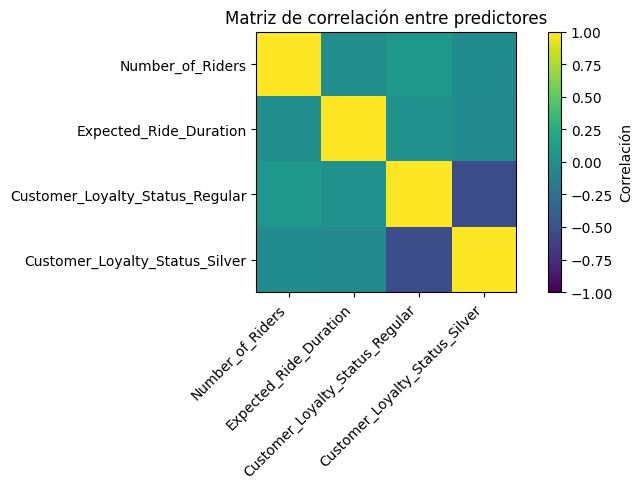


VIF:


,Variable,VIF
0,const,13.902805
1,Number_of_Riders,1.005060
2,Expected_Ride_Duration,1.001939
3,Customer_Loyalty_Status_Regular,1.380503
4,Customer_Loyalty_Status_Silver,1.377267


In [ ]:
corr = X.corr()

print("Matriz de correlación:")
display(corr)

plt.figure(figsize=(8, 5))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar(label="Correlación")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlación entre predictores")
plt.tight_layout()
plt.show()

vif_df = pd.DataFrame()
vif_df["Variable"] = X_const.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

print("\nVIF:")
display(vif_df)

outliers: []
Puntos con alto leverage: []
Observaciones influyentes por Cook: [ 20 124 271 593 689 712 867 946 959]


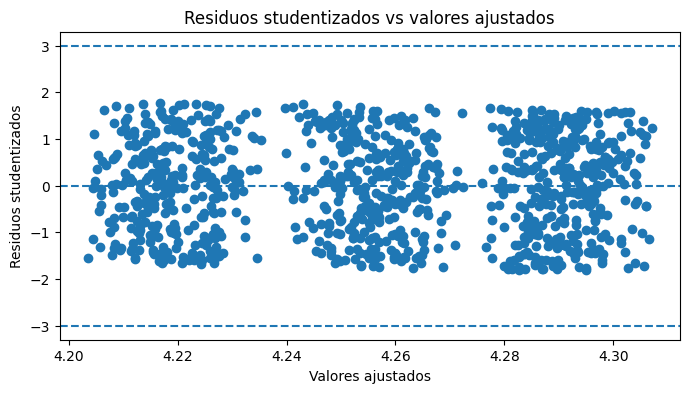

In [ ]:
influencia = modelo.get_influence()

res_student = influencia.resid_studentized_external
leverage = influencia.hat_matrix_diag
cooks = influencia.cooks_distance[0]

n = len(data_model)
p = X_const.shape[1]

umbral_leverage = 2 * p / n
umbral_cook = 4 / n

outliers = np.where(np.abs(res_student) > 3)[0]
puntos_leverage = np.where(leverage > umbral_leverage)[0]
puntos_cook = np.where(cooks > umbral_cook)[0]

print("outliers:", outliers)
print("Puntos con alto leverage:", puntos_leverage)
print("Observaciones influyentes por Cook:", puntos_cook)

plt.figure(figsize=(8, 4))
plt.scatter(modelo.fittedvalues, res_student)
plt.axhline(0, linestyle="--")
plt.axhline(3, linestyle="--")
plt.axhline(-3, linestyle="--")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos studentizados")
plt.title("Residuos studentizados vs valores ajustados")
plt.show()


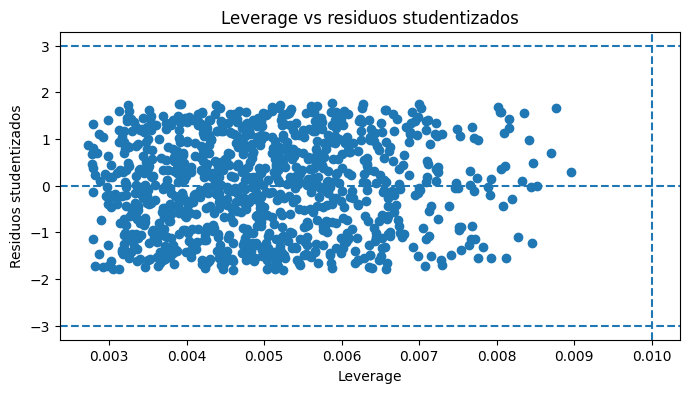

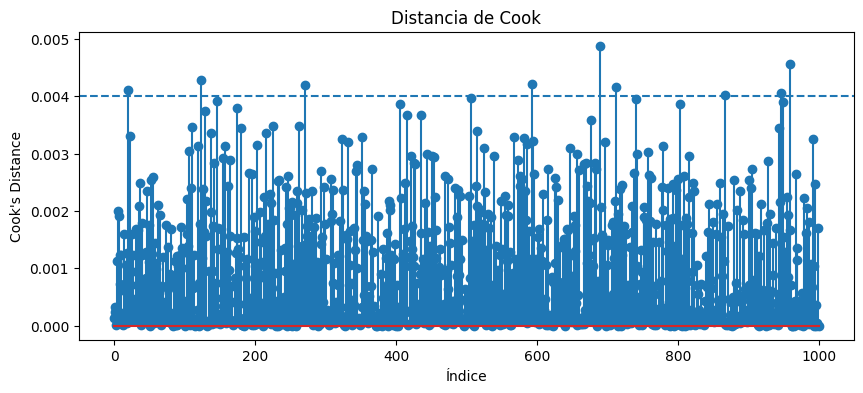


Cinco observaciones más incluyentes:


,Average_Ratings,Number_of_Riders,Expected_Ride_Duration,Customer_Loyalty_Status
689,4.96,21,180,Regular
959,4.97,22,170,Regular
124,5.00,26,161,Regular
593,3.56,92,19,Silver
271,3.52,100,163,Regular


In [ ]:
plt.figure(figsize=(8, 4))
plt.scatter(leverage, res_student)
plt.axhline(0, linestyle="--")
plt.axhline(3, linestyle="--")
plt.axhline(-3, linestyle="--")
plt.axvline(umbral_leverage, linestyle="--")
plt.xlabel("Leverage")
plt.ylabel("Residuos studentizados")
plt.title("Leverage vs residuos studentizados")
plt.show()

plt.figure(figsize=(10, 4))
plt.stem(np.arange(len(cooks)), cooks)
plt.axhline(umbral_cook, linestyle="--")
plt.xlabel("Índice")
plt.ylabel("Cook's Distance")
plt.title("Distancia de Cook")
plt.show()

idx_top = np.argsort(cooks)[-5:][::-1]
print("\nCinco observaciones más incluyentes:")
display(data_model.iloc[idx_top])

# 2.4 Evaluación de supuestos del modelo

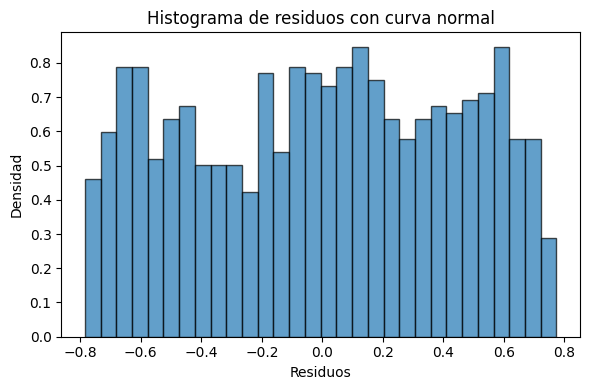

In [ ]:
import scipy.stats as stats

# Residuos del modelo
resid = modelo.resid

# --------- Histograma de residuos ----------
plt.figure(figsize=(6, 4))
plt.hist(resid, bins=30, edgecolor="black", alpha=0.7, density=True)
mu, sigma = np.mean(resid), np.std(resid)
xmin, xmax = plt.xlim()
x_vals = np.linspace(xmin, xmax, 100)
plt.xlabel("Residuos")
plt.ylabel("Densidad")
plt.title("Histograma de residuos con curva normal")
plt.tight_layout()
plt.show()



<Figure size 600x400 with 0 Axes>

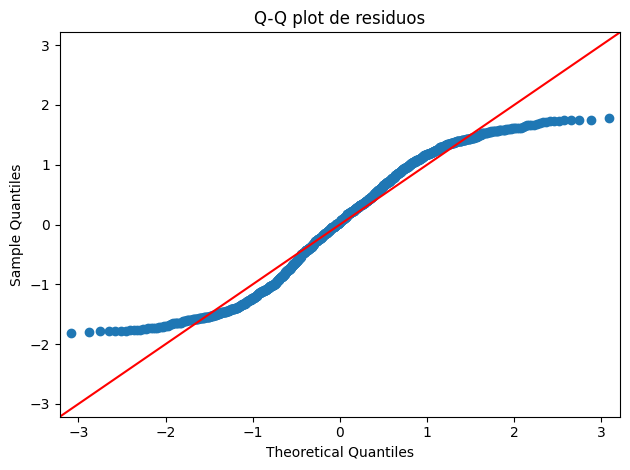

Estadístico de Shapiro-Wilk: 0.95633
p-valor: 0.00000
Se rechaza H0: los residuos NO siguen una distribución normal (α = 0.05).


In [ ]:
 #--------- Q-Q plot de residuos ----------
plt.figure(figsize=(6, 4))
sm.qqplot(resid, line="45", fit=True)
plt.title("Q-Q plot de residuos")
plt.tight_layout()
plt.show()

from scipy.stats import shapiro

# Supongamos que ya ajustaste el modelo OLS con statsmodels
# modelo = sm.OLS(y, X_const).fit()

# 1. Obtener los residuos del modelo
residuos = modelo.resid

# 2. Aplicar la prueba de Shapiro-Wilk
stat, p_value = shapiro(residuos)

print(f"Estadístico de Shapiro-Wilk: {stat:.5f}")
print(f"p-valor: {p_value:.5f}")

# 3. Interpretación rápida
alpha = 0.05
if p_value < alpha:
    print("Se rechaza H0: los residuos NO siguen una distribución normal (α = 0.05).")
else:
    print("No se rechaza H0: los residuos son compatibles con la normalidad (α = 0.05).")

## 2.4.2 Homoecedasticidad

Breusch-Pagan:


,LM statistic,LM p-value,F statistic,F p-value
0,9.870991,0.042658,2.479888,0.042492


Interpretación: existe evidencia de heterocedasticidad.


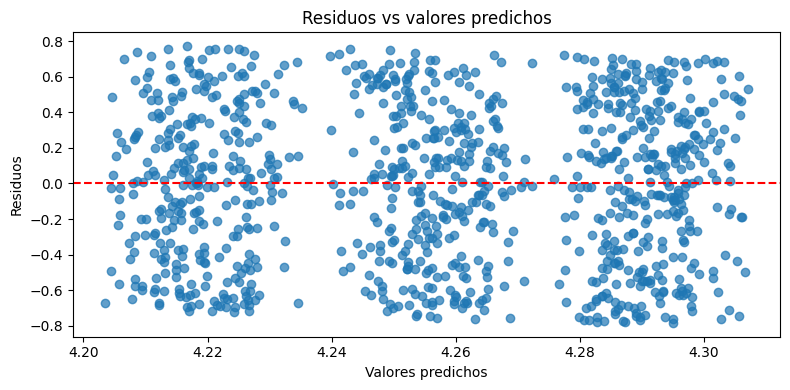

In [ ]:
# Residuos y valores predichos
resid = modelo.resid
predichos = modelo.fittedvalues   # <- ESTA variable se usará en el scatter

# ---- Test de Breusch-Pagan ----
bp_test = het_breuschpagan(resid, modelo.model.exog)

bp_labels = ["LM statistic", "LM p-value",
             "F statistic", "F p-value"]
bp_results = dict(zip(bp_labels, bp_test))

print("Breusch-Pagan:")
display(pd.DataFrame([bp_results]))

if bp_results["LM p-value"] < 0.05:
    print("Interpretación: existe evidencia de heterocedasticidad.")
else:
    print("Interpretación: no se evidencia heterocedasticidad significativa.")

# ---- Gráfico residuos vs valores predichos ----
plt.figure(figsize=(8, 4))
plt.scatter(predichos, resid, alpha=0.7)
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs valores predichos")
plt.tight_layout()
plt.show()

El supuesto de homocedasticidad. Uno de los supuestos sobre los que descansa la regresión lineal múltiple es el de homocedasticidad, que significa que la varianza de los errores del modelo se mantiene constante a lo largo de todos los valores predichos. En términos sencillos, el modelo debería equivocarse "más o menos lo mismo" tanto cuando predice valores bajos como cuando predice valores altos. Cuando este supuesto no se cumple —situación denominada heterocedasticidad—, la dispersión de los errores cambia según el valor predicho y, como consecuencia, los errores estándar de los coeficientes dejan de ser confiables. Esto distorsiona las pruebas de significancia (t y F) y los intervalos de confianza, por lo que verificar la homocedasticidad es parte esencial de la evaluación de la validez de la inferencia del modelo.

Lectura del gráfico de residuos frente a valores predichos. La gráfica representa los residuos del modelo (eje vertical) frente a los valores predichos (eje horizontal), con una línea de referencia en cero. Se observan dos rasgos. Primero, los residuos se reparten de forma aproximadamente simétrica por encima y por debajo de cero, sin una tendencia o curvatura evidente. Segundo, los puntos se agrupan en bandas verticales y ocupan un rango de predicción muy estrecho (entre 4.20 y 4.31 aproximadamente); esto es consecuencia directa de la naturaleza del modelo: como la variable de lealtad del cliente es categórica y los predictores continuos tienen coeficientes prácticamente nulos, las predicciones se concentran en unos pocos valores cercanos a la calificación media. A simple vista, la amplitud vertical de la nube parece relativamente similar entre bandas, de modo que la inspección visual por sí sola no permite afirmar con seguridad si la varianza es constante. Precisamente por esta ambigüedad se recurre a una prueba estadística formal.

Resultado de la prueba de Breusch-Pagan. La prueba de Breusch-Pagan contrasta la hipótesis nula de homocedasticidad (varianza constante de los errores) frente a la alternativa de heterocedasticidad. Los resultados obtenidos son un estadístico LM de 9.871 con un p-valor de 0.0427, y un estadístico F de 2.480 con un p-valor de 0.0425. Como ambos p-valores son inferiores al nivel de significancia convencional de 0.05, se rechaza la hipótesis nula y se concluye que existe evidencia de heterocedasticidad en los residuos del modelo. No obstante, conviene matizar que esta evidencia es marginal, ya que los p-valores se sitúan muy cerca del umbral de 0.05. La implicación metodológica es relevante para los objetivos de este trabajo: ante la presencia de heterocedasticidad, los errores estándar calculados por mínimos cuadrados ordinarios pierden fiabilidad, lo que justifica complementar el análisis con métodos de inferencia robustos —en particular, el remuestreo bootstrap por pares (case resampling)— que no dependen del supuesto de varianza constante para estimar la incertidumbre de los coeficientes.

In [ ]:
dw = durbin_watson(resid)
print("Durbin-Watson:", dw)
if 1.5 <= dw <= 2.5:
  print("Interpretación: no se observa evidencia fuerte de autocorrelación.")
elif dw < 1.5:
  print("Interpretación: posible autocorrelación positiva.")
else:
  print("Interpretación:posible autocorrelación negativa.")


Durbin-Watson: 1.9994451568217761
Interpretación: no se observa evidencia fuerte de autocorrelación.


# 2.5 Mejora del modelo


In [ ]:
from scipy.stats import shapiro
y_log = np.log(y + 1e-6)

modelo_log = sm.OLS(y_log, X_const).fit()

print("Modelo logarítmico:")
print(modelo_log.summary())

# Test de normalidad y heterocedasticidad en el modelo logarítmico
print("Shapiro log p-value:", shapiro(modelo_log.resid)[1])

bp_log = het_breuschpagan(modelo_log.resid, modelo_log.model.exog)
print("Breusch-Pagan log p-value:", bp_log[1])

# Comparación de métricas entre original y logarítmico
comparacion_final = pd.DataFrame({
    "Modelo": ["OLS original", "Logarítmico"],
    "R²": [modelo.rsquared, modelo_log.rsquared],
    "R² ajustado": [modelo.rsquared_adj, modelo_log.rsquared_adj],
    "AIC": [modelo.aic, modelo_log.aic],
    "BIC": [modelo.bic, modelo_log.bic]
})

display(comparacion_final)

Modelo logarítmico:
                            OLS Regression Results                            
Dep. Variable:        Average_Ratings   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.179
Date:                Thu, 11 Jun 2026   Prob (F-statistic):              0.318
Time:                        18:59:10   Log-Likelihood:                 851.55
No. Observations:                1000   AIC:                            -1693.
Df Residuals:                     995   BIC:                            -1669.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

,Modelo,R²,R² ajustado,AIC,BIC
0,OLS original,0.004893,0.000892,1180.740281,1205.279058
1,Logarítmico,0.004718,0.000716,-1693.098141,-1668.559364


Modelo logarítmico. Con el fin de intentar mejorar el modelo, se aplicó una transformación logarítmica a la variable dependiente y se reestimó la regresión. Sin embargo, el poder explicativo no mejoró: el R² se mantuvo en torno a 0.005 y la prueba F siguió siendo no significativa (p = 0.318), de modo que el modelo logarítmico tampoco logra explicar la variación en las calificaciones. Es importante aclarar que, aunque los valores de AIC y BIC del modelo logarítmico son mucho menores que los del modelo original, esta diferencia no debe interpretarse como una mejora, ya que el AIC y el BIC no son comparables entre modelos con distinta variable dependiente: el cambio se debe únicamente a la transformación de escala y no a un mejor ajuste.

El principal cambio favorable se observó en el supuesto de homocedasticidad. Tras la transformación, la prueba de Breusch-Pagan arrojó un p-valor de 0.066, superior a 0.05, por lo que ya no se detecta heterocedasticidad en los residuos. En cambio, el supuesto de normalidad continúa sin cumplirse, pues las pruebas de Shapiro-Wilk y Jarque-Bera lo rechazan claramente. En conjunto, la transformación logarítmica estabiliza la varianza de los errores, pero no resuelve el problema de fondo: las variables seleccionadas no tienen capacidad para predecir la calificación promedio.

## Remediación del modelo Box_Cox

In [ ]:
from scipy.stats import boxcox, shapiro
from statsmodels.stats.diagnostic import het_breuschpagan

# Box-Cox solo admite valores > 0, por eso sumamos un epsilon si hiciera falta
y_pos = y + 1e-6

y_bc, lambda_bc = boxcox(y_pos)

print("Lambda óptimo Box-Cox:", lambda_bc)

modelo_bc = sm.OLS(y_bc, X_const).fit()

print("Modelo Box-Cox:")
print(modelo_bc.summary())

print("Shapiro Box-Cox p-value:", shapiro(modelo_bc.resid)[1])

bp_bc = het_breuschpagan(modelo_bc.resid, modelo_bc.model.exog)
print("Breusch-Pagan Box-Cox p-value:", bp_bc[1])

# Comparación de los tres modelos
comparacion_final = pd.DataFrame({
    "Modelo": ["OLS original", "Logarítmico", "Box-Cox"],
    "R²": [modelo.rsquared, modelo_log.rsquared, modelo_bc.rsquared],
    "R² ajustado": [modelo.rsquared_adj, modelo_log.rsquared_adj, modelo_bc.rsquared_adj],
    "AIC": [modelo.aic, modelo_log.aic, modelo_bc.aic],
    "BIC": [modelo.bic, modelo_log.bic, modelo_bc.bic]
})

display(comparacion_final)

Lambda óptimo Box-Cox: 1.2249136768281148
Modelo Box-Cox:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.234
Date:                Thu, 11 Jun 2026   Prob (F-statistic):              0.295
Time:                        18:59:57   Log-Likelihood:                -909.75
No. Observations:                1000   AIC:                             1829.
Df Residuals:                     995   BIC:                             1854.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

,Modelo,R²,R² ajustado,AIC,BIC
0,OLS original,0.004893,0.000892,1180.740281,1205.279058
1,Logarítmico,0.004718,0.000716,-1693.098141,-1668.559364
2,Box-Cox,0.004935,0.000935,1829.497164,1854.035940


## Opción 2. Modelo Robusto RLM

In [ ]:
import statsmodels.api as sm

# Modelo robusto RLM con función de pérdida Huber
modelo_rlm = sm.RLM(
    y,
    X_const,
    M=sm.robust.norms.HuberT()
).fit()

print("Modelo robusto RLM:")
display(modelo_rlm.summary())

comparacion_coef = pd.DataFrame({
    "OLS": modelo.params,
    "RLM": modelo_rlm.params
})

display(comparacion_coef)

Modelo robusto RLM:


<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:        Average_Ratings   No. Observations:                 1000
Model:                            RLM   Df Residuals:                      995
Method:                          IRLS   Df Model:                            4
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Thu, 11 Jun 2026                                         
Time:                        19:03:30                                         
No. Iterations:                     8                                         
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                               4.2229      0.052     80.573      0.000       4.120       4.326
Number_of_Riders                    0.0001      0.001      0.247      0.805      -0.001       0.001
Expected_Ride_Duration             -0.0001      0.000     -0.438      0.661      -0.001       0.000
Customer_Loyalty_Status_Regular     0.0366      0.035      1.034      0.301      -0.033       0.106
Customer_Loyalty_Status_Silver      0.0721      0.034      2.106      0.035       0.005       0.139
===================================================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

,OLS,RLM
const,4.222885,4.222881
Number_of_Riders,0.000150,0.000147
Expected_Ride_Duration,-0.000126,-0.000125
Customer_Loyalty_Status_Regular,0.036439,0.036608
Customer_Loyalty_Status_Silver,0.071388,0.072071


In [ ]:
n_boot = 1000
n = len(data_model)
coef_boot = []

for i in range(n_boot):
    idx = np.random.choice(range(n), n, replace=True)
    Xb = X_const.iloc[idx]
    yb = y.iloc[idx]
    mb = sm.OLS(yb, Xb).fit()
    coef_boot.append(mb.params.values)

coef_boot = np.array(coef_boot)

ic_boot = []

for j, name in enumerate(modelo.params.index):
    li = np.percentile(coef_boot[:, j], 2.5)
    ls = np.percentile(coef_boot[:, j], 97.5)
    ic_boot.append([name, modelo.params[name], li, ls])

tabla_boot = pd.DataFrame(
    ic_boot,
    columns=["Coeficiente", "Beta original", "IC 2.5%", "IC 97.5%"]
)

display(tabla_boot)

,Coeficiente,Beta original,IC 2.5%,IC 97.5%
0,const,4.222885,4.122853,4.327685
1,Number_of_Riders,0.000150,-0.001076,0.001343
2,Expected_Ride_Duration,-0.000126,-0.000665,0.000420
3,Customer_Loyalty_Status_Regular,0.036439,-0.031672,0.103953
4,Customer_Loyalty_Status_Silver,0.071388,0.004013,0.136675


## Comparación Final del modelo